## Notes
1- TARGET_SIZE in cell 2 controls output size in cell 6.

2- if you want to reduce the feature map resolution that is input to any up you can use downsampled_lr_features_3d in cell 5c, don't forget to change other cells 6,7 and 8

3- q_chunk_size reduces memory usage

4- if you want to modify output size just find anyup forward pass in cell 6



In [1]:
# ============================================================
# Cell 1 — Install dependencies + clone YOUR repo
# ============================================================
!git clone https://github.com/mu-az88/anyup.git
%cd anyup
!pip install -e . --quiet
!pip install transformers matplotlib scikit-learn --quiet
!apt-get install -y ffmpeg --quiet

Cloning into 'anyup'...
remote: Enumerating objects: 445, done.
remote: Counting objects: 100% (223/223), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 445 (delta 109), reused 167 (delta 65), pack-reused 222 (from 1)
Receiving objects: 100% (445/445), 32.61 MiB | 18.60 MiB/s, done.
Resolving deltas: 100% (220/220), done.
/content/anyup
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.7 MB/s eta 0:00:00
  Building editable for anyup (pyproject.toml) ... done
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [2]:
# ============================================================
# Cell 2 — Imports & device
# ============================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
import subprocess, os, glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
TARGET_SIZE   = 224

Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Saving aigc_1.mp4 to aigc_1.mp4
Uploaded: aigc_1.mp4
Extracted 2 frames
Video tensor: torch.Size([1, 3, 2, 224, 224])


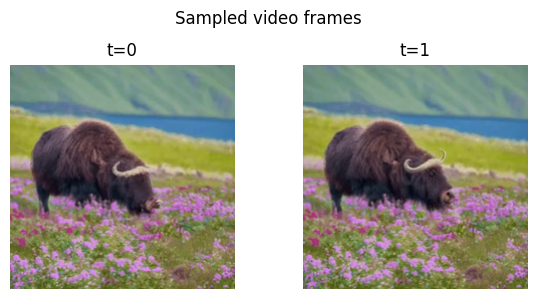

In [4]:
# ============================================================
# Cell 3 — Upload a video and extract T evenly-spaced frames
# ============================================================
from google.colab import files

uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"Uploaded: {video_path}")

# --- Config ---
T          = 8     # number of frames to sample (keep ≤ 16 to avoid OOM)
frames_dir = "/tmp/anyup_frames"
os.makedirs(frames_dir, exist_ok=True)

# Use ffmpeg to extract T evenly-spaced frames
subprocess.run([
    "ffmpeg", "-y", "-i", video_path,
    "-vf", f"select=not(mod(n\\,1)),fps=1",   # 1 fps; adjust as needed
    "-vframes", str(T),
    f"{frames_dir}/frame_%04d.png"
], check=True, capture_output=True)

frame_paths = sorted(glob.glob(f"{frames_dir}/frame_*.png"))[:T]
T = len(frame_paths)   # actual count after extraction
print(f"Extracted {T} frames")

# Load & normalize all frames → (T, 3, H, W)
def load_frame(path):
    img = Image.open(path).convert("RGB").resize((TARGET_SIZE, TARGET_SIZE), Image.BICUBIC)
    t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    return (t - IMAGENET_MEAN) / IMAGENET_STD

frames = torch.stack([load_frame(p) for p in frame_paths])  # (T, 3, H, W)

# AnyUp3D expects (B, 3, T, H, W) — add batch dim and move T inside
video_3d = frames.unsqueeze(0).permute(0, 2, 1, 3, 4)  # (1, 3, T, 224, 224)
# Note: frames has shape (T, 3, H, W), so:
#   unsqueeze(0) → (1, T, 3, H, W)
#   permute(0,2,1,3,4) → (1, 3, T, H, W)  ✓
print(f"Video tensor: {video_3d.shape}")   # (1, 3, T, 224, 224)

# Preview the sampled frames
fig, axes = plt.subplots(1, T, figsize=(3 * T, 3))
for i, ax in enumerate(axes):
    vis = (frames[i].permute(1,2,0) * IMAGENET_STD.squeeze() + IMAGENET_MEAN.squeeze()).clamp(0,1)
    ax.imshow(vis.numpy()); ax.axis("off"); ax.set_title(f"t={i}")
plt.suptitle("Sampled video frames"); plt.tight_layout(); plt.show()

In [5]:
# ============================================================
# Cell 4 — Extract 3D features with VideoMAE
# ============================================================
# VideoMAE ViT-B/16 with tubelet size (2, 16, 16):
#   Input  : (B, C, T=16, H=224, W=224)
#   Patches: T'= 16//2 = 8,  H'= 224//16 = 14,  W'= 224//16 = 14
#   Tokens : (B, 8*14*14, 768)  →  reshaped to  (B, 768, 8, 14, 14)  ✓
#
# This is a genuine spatiotemporal feature map — no per-frame tricks.

from transformers import VideoMAEModel, AutoImageProcessor

VIDEOMAE_NAME = "MCG-NJU/videomae-base"   # ViT-B, pretrained on Kinetics-400
T_MODEL       = 16                         # VideoMAE expects exactly 16 frames

processor   = AutoImageProcessor.from_pretrained(VIDEOMAE_NAME)
videomae    = VideoMAEModel.from_pretrained(VIDEOMAE_NAME).to(device).eval()

print(f"VideoMAE loaded — hidden size: {videomae.config.hidden_size}")   # 768
print(f"Tubelet size: {videomae.config.tubelet_size}")                   # 2
print(f"Patch size:   {videomae.config.patch_size}")                     # 16

# ── Resample the extracted frames to exactly T_MODEL frames ──────────────
# frames shape is (T_extracted, 3, H, W) — we resample to (T_MODEL, 3, H, W)
frames_model = F.interpolate(
    frames.permute(1, 0, 2, 3).unsqueeze(0),      # (1, 3, T, H, W) ✓
    size=(T_MODEL, TARGET_SIZE, TARGET_SIZE),
    mode="trilinear", align_corners=False
).squeeze(0).permute(1, 0, 2, 3)                                       # (T_MODEL, 3, H, W)

# Denormalize back to uint8 PIL frames for the processor
def to_pil_frames(t_c_h_w):
    """(T, 3, H, W) normalized tensor → list of PIL Images"""
    imgs = (t_c_h_w.permute(0, 2, 3, 1)
            * IMAGENET_STD.squeeze() + IMAGENET_MEAN.squeeze()).clamp(0, 1)
    return [Image.fromarray((f.numpy() * 255).astype(np.uint8)) for f in imgs]

pil_frames = to_pil_frames(frames_model)   # list of 16 PIL Images

# Run through VideoMAE processor (handles normalization internally)
inputs = processor(pil_frames, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)   # (1, T, H, W, C) or (1, C, T, H, W)
                                                    # exact layout depends on transformers version

# Extract patch tokens (no CLS)
with torch.no_grad():
    outputs   = videomae(pixel_values=pixel_values, output_hidden_states=False)
    tokens    = outputs.last_hidden_state           # (1, T'*H'*W', 768)

# Compute expected patch grid dimensions
tubelet = videomae.config.tubelet_size              # 2
patch   = videomae.config.patch_size                # 16
T_prime = T_MODEL  // tubelet                       # 16 // 2 = 8
H_prime = TARGET_SIZE // patch                      # 224 // 16 = 14
W_prime = TARGET_SIZE // patch                      # 224 // 16 = 14

assert tokens.shape[1] == T_prime * H_prime * W_prime, \
    f"Unexpected token count: {tokens.shape[1]} vs {T_prime}×{H_prime}×{W_prime}"

# Reshape to spatial 3D feature map: (B, 768, T', H', W')
lr_features_3d = (tokens
                  .reshape(1, T_prime, H_prime, W_prime, -1)
                  .permute(0, 4, 1, 2, 3))          # (1, 768, 8, 14, 14)

print(f"VideoMAE 3D features: {lr_features_3d.shape}")  # (1, 768, 8, 14, 14)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

The image processor of type `VideoMAEImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEModel LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     |  | 
---------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.bias          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.weight    | UNEXPECTED |  | 
mask_token                                                           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.norm.weight                                                  | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.v_bias    

VideoMAE loaded — hidden size: 768
Tubelet size: 2
Patch size:   16
VideoMAE 3D features: torch.Size([1, 768, 8, 14, 14])


Guide video tensor : torch.Size([1, 3, 8, 224, 224])
LR features tensor : torch.Size([1, 768, 8, 14, 14])


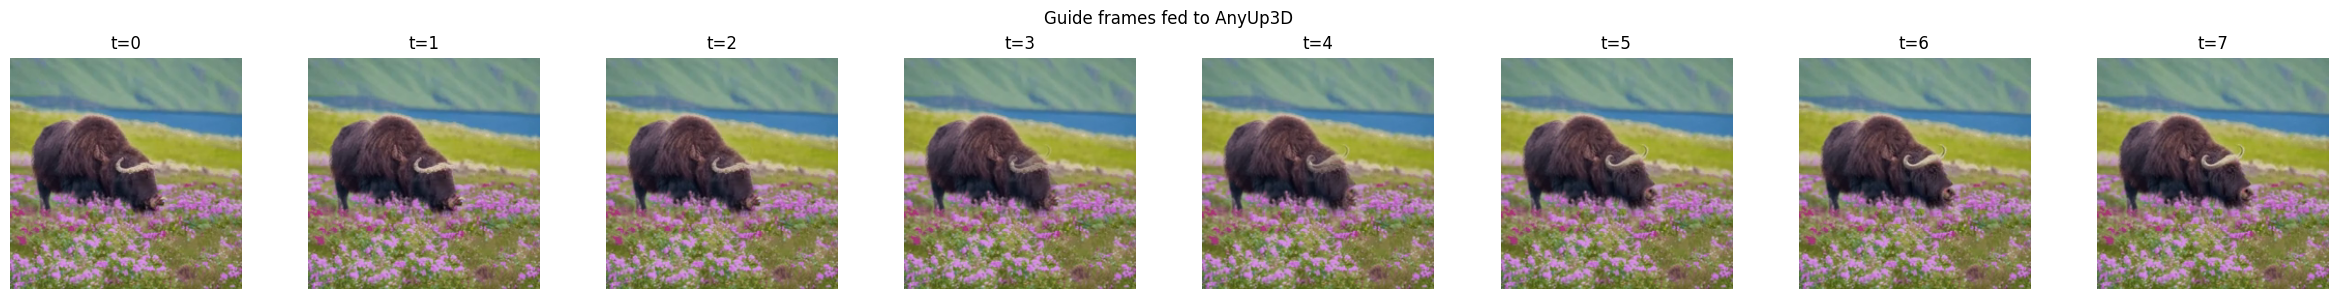

In [6]:
# ============================================================
# Cell 5 — Build the 3D video tensor to match VideoMAE's T
# ============================================================
# We also need the guide image to have the same T as the features.
# VideoMAE collapsed T=16 → T'=8 via the tubelet. We match that.

video_3d = frames_model.permute(1, 0, 2, 3).unsqueeze(0)   # (1, 3, T_MODEL, H, W)
# frames_model: (16, 3, H, W)
# unsqueeze(0) → (1, 16, 3, H, W)
# permute      → (1, 3, 16, H, W)

# Downsample the guide video temporally to match T'=8 (the feature T)
video_3d = F.interpolate(
    video_3d.float(),
    size=(T_prime, TARGET_SIZE, TARGET_SIZE),
    mode="trilinear", align_corners=False
)                                                   # (1, 3, 8, 224, 224)

video_3d = video_3d.to(device)
print(f"Guide video tensor : {video_3d.shape}")     # (1, 3,   8, 224, 224)
print(f"LR features tensor : {lr_features_3d.shape}")  # (1, 768, 8,  14,  14)

# Quick preview of the 8 resampled guide frames
guide_frames = video_3d[0].permute(1, 0, 2, 3).cpu()  # (8, 3, H, W)
fig, axes = plt.subplots(1, T_prime, figsize=(3 * T_prime, 3))
for i, ax in enumerate(axes):
    vis = (guide_frames[i].permute(1,2,0) * IMAGENET_STD.squeeze()
           + IMAGENET_MEAN.squeeze()).clamp(0, 1).numpy()
    ax.imshow(vis); ax.axis("off"); ax.set_title(f"t={i}")
plt.suptitle("Guide frames fed to AnyUp3D"); plt.tight_layout(); plt.show()

In [7]:
import torch.nn.functional as F

# ============================================================
# Cell 5c — Downsample LR features for AnyUp3D input
# ============================================================
# Define the new target spatial resolution for the LR features (e.g., 7x7)
# This will be the spatial resolution for the input to the AnyUp3D model.
new_lr_spatial_resolution = 7  # Original is 14x14

if new_lr_spatial_resolution < lr_features_3d.shape[-1]:
    # Downsample lr_features_3d spatially using trilinear interpolation
    downsampled_lr_features_3d = F.interpolate(
        lr_features_3d,
        size=(T_prime, new_lr_spatial_resolution, new_lr_spatial_resolution),
        mode="trilinear",
        align_corners=False
    )
    print(f"Downsampled LR features: {downsampled_lr_features_3d.shape}")
else:
    downsampled_lr_features_3d = lr_features_3d
    print(f"LR features unchanged: {downsampled_lr_features_3d.shape}")

Downsampled LR features: torch.Size([1, 768, 8, 7, 7])


In [8]:
# ============================================================
# Cell 5a — Instantiate AnyUp3D  (run this before Cell 6)
# ============================================================
from anyup.model import AnyUp
from anyup.modules import create_coordinates_3d

model = AnyUp(
    input_dim=3,
    qk_dim=128,
    kernel_size=1,
    kernel_size_lfu=5,
    window_ratio=0.1,
    num_heads=4,
    t_k=3, # Changed back to 3 to match the checkpoint's temporal kernel size based on error analysis
    window_t=4
).to(device).eval()

total = sum(p.numel() for p in model.parameters())
print(f"AnyUp3D parameters: {total:,}")

AnyUp3D parameters: 1,540,736


In [9]:
# ============================================================
# Cell 5b — Load trained AnyUp3D weights (correct TStage)
# ============================================================
from dataclasses import dataclass

@dataclass
class TStage:
    t: int
    start_step: int
    batch_size: int

import __main__
__main__.TStage = TStage

ckpt_path = "/content/drive/MyDrive/anyup3d/checkpoints/run_02/anyup3d_step6000.pth"
# ← update if your path is different

checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
print(f"Checkpoint keys: {list(checkpoint.keys())}")

# Extract model weights
if "anyup" in checkpoint:
    state_dict = checkpoint["anyup"]
elif "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
elif "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint

missing, unexpected = model.load_state_dict(state_dict, strict=True)

print(f"✓ Weights loaded: anyup3d_step6000.pth")
print(f"  Missing keys   : {len(missing)}")
print(f"  Unexpected keys: {len(unexpected)}")
if missing:
    print(f"  ⚠ Missing: {missing[:5]}")
if unexpected:
    print(f"  ⚠ Unexpected: {unexpected[:5]}")

model.eval()
print("✓ Model set to eval mode")

Checkpoint keys: ['anyup', 'optimizer', 'scheduler', 'global_step', 'data_epoch', 'cfg']
✓ Weights loaded: anyup3d_step6000.pth
  Missing keys   : 0
  Unexpected keys: 0
✓ Model set to eval mode


In [10]:
# ============================================================
# Cell 6 — AnyUp3D forward pass (unchanged)
# ============================================================
with torch.no_grad():
    hr_features_3d = model(
        video_3d,
        lr_features_3d.to(device),
        output_size=(TARGET_SIZE, TARGET_SIZE),
        q_chunk_size=128,   # ← halve to 512 or 256 if still OOM
    )
print(f"Output: {hr_features_3d.shape}")
hr_features_3d = hr_features_3d.cpu()

Output: torch.Size([1, 768, 8, 224, 224])


Fitting PCA on low-res features ...
Fitting PCA on high-res features ...


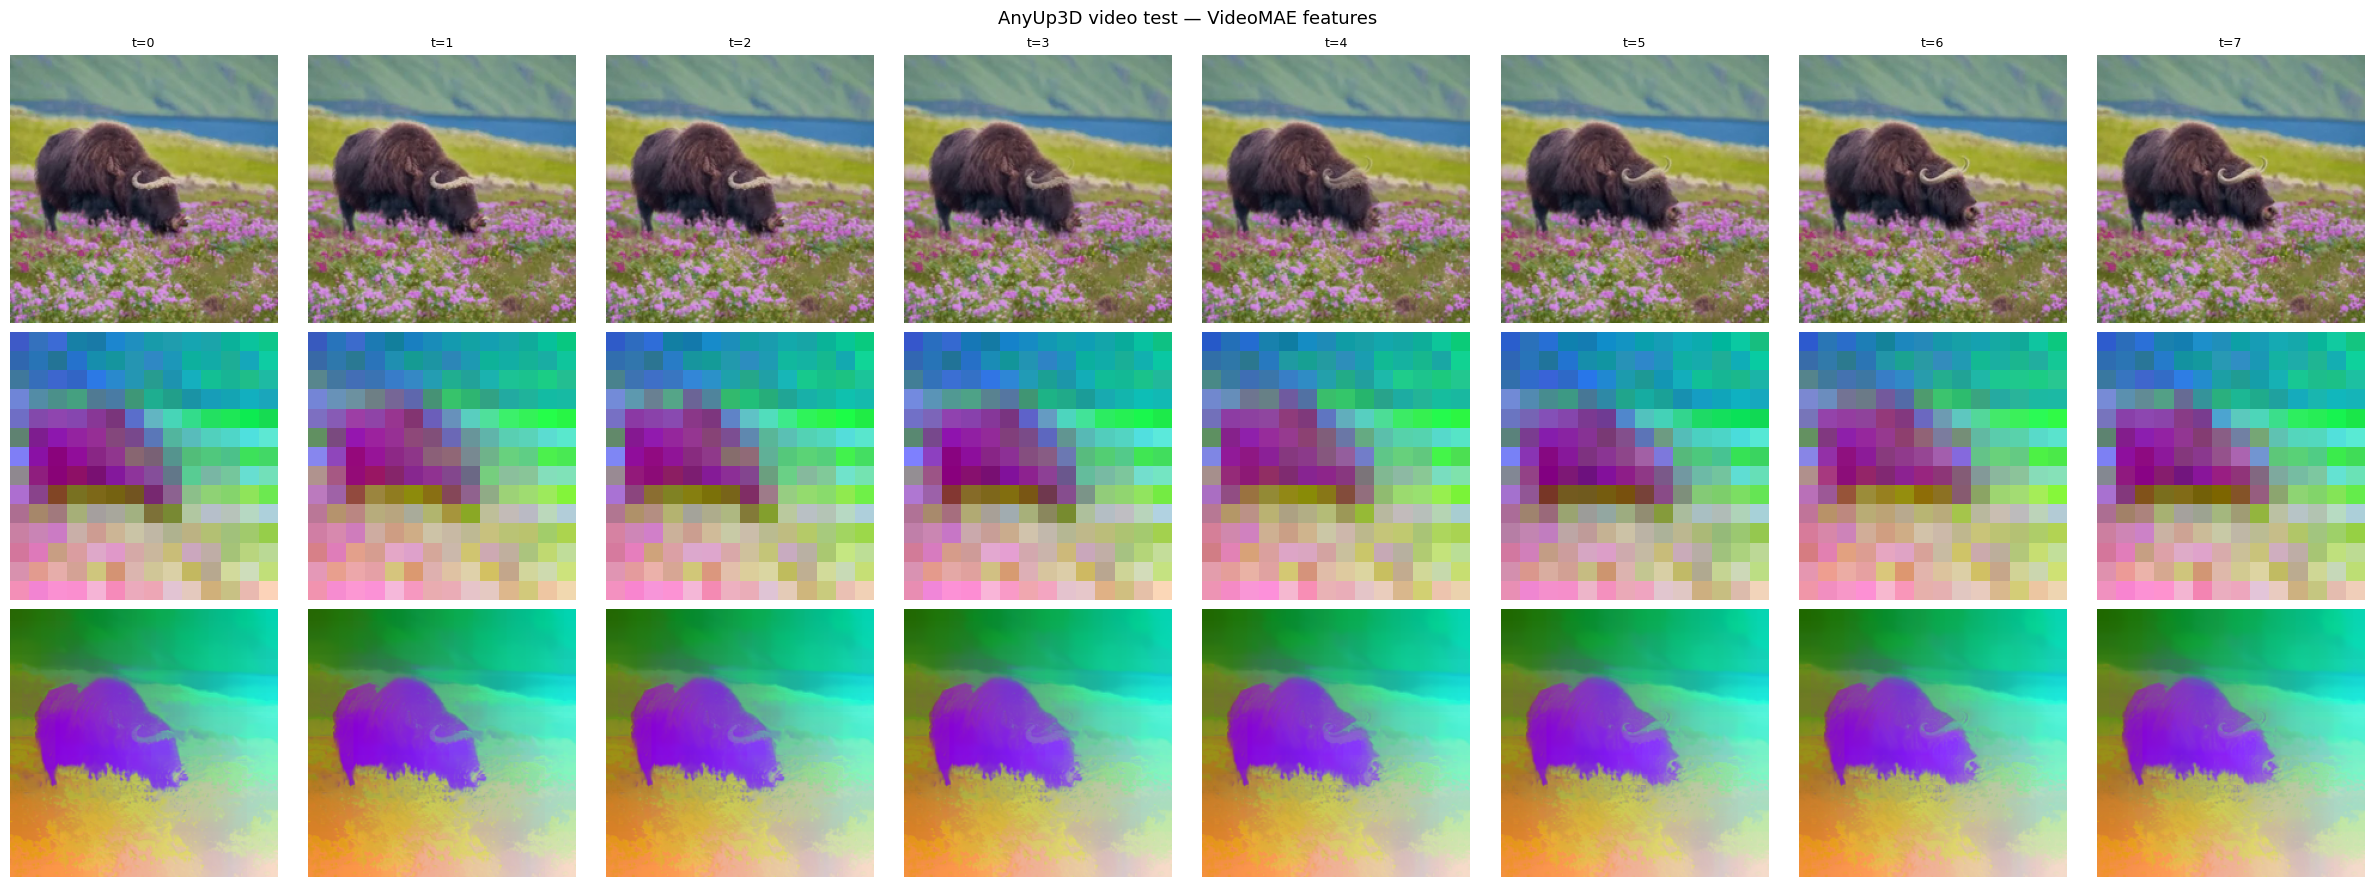

In [11]:
# ============================================================
# Cell 7 — PCA visualization (VideoMAE version)
# ============================================================
C_feat = hr_features_3d.shape[1]

# ✗ Old CLIP variables — no longer exist
# lr_all = lr_per_frame.cpu()
# hr_all = hr_features_3d[0].permute(1, 0, 2, 3)

# ✓ VideoMAE equivalents
# lr_features_3d: (1, 768, T', 14, 14)  → (T', 768, 14, 14)
# hr_features_3d: (1, 768, T', H,  W)   → (T', 768, H,  W)
lr_all = lr_features_3d[0].permute(1, 0, 2, 3).cpu()   # (T', 768, 14, 14)
hr_all = hr_features_3d[0].permute(1, 0, 2, 3).cpu()   # (T', 768, H,  W)

# Also update the frame source for the preview row
# frames_model: (T_MODEL=16, 3, H, W) — subsample to T' frames for display
frame_indices = np.linspace(0, T_MODEL - 1, T_prime, dtype=int)
display_frames = frames_model[frame_indices]            # (T', 3, H, W)

def fit_pca_jointly(feat_t_c_h_w):
    """
    feat_t_c_h_w : (T, C, H, W)
    Fits PCA across all T*H*W tokens jointly.
    Returns (T, H, W, 3) RGB array.
    """
    T, C, H, W = feat_t_c_h_w.shape
    flat = feat_t_c_h_w.permute(0, 2, 3, 1).reshape(-1, C).numpy()  # (T*H*W, C)
    pcs  = PCA(n_components=3).fit_transform(flat)                    # (T*H*W, 3)
    pcs -= pcs.min(0); pcs /= (pcs.max(0) + 1e-6)
    return pcs.reshape(T, H, W, 3)

def fit_pca_jointly(feat_t_c_h_w):
    T, C, H, W = feat_t_c_h_w.shape
    flat = feat_t_c_h_w.permute(0, 2, 3, 1).reshape(-1, C).numpy()
    pcs  = PCA(n_components=3).fit_transform(flat)
    pcs -= pcs.min(0); pcs /= (pcs.max(0) + 1e-6)
    return pcs.reshape(T, H, W, 3)

print("Fitting PCA on low-res features ...")
lr_pca = fit_pca_jointly(lr_all)    # (T', 14, 14, 3)
print("Fitting PCA on high-res features ...")
hr_pca = fit_pca_jointly(hr_all)    # (T', H, W, 3)

fig, axes = plt.subplots(3, T_prime, figsize=(3 * T_prime, 9))

for i in range(T_prime):
    vis = (display_frames[i].permute(1, 2, 0) * IMAGENET_STD.squeeze()
           + IMAGENET_MEAN.squeeze()).clamp(0, 1).numpy()
    axes[0, i].imshow(vis);        axes[0, i].axis("off"); axes[0, i].set_title(f"t={i}", fontsize=9)
    axes[1, i].imshow(lr_pca[i]); axes[1, i].axis("off")
    axes[2, i].imshow(hr_pca[i]); axes[2, i].axis("off")

axes[0, 0].set_ylabel("Input frame",            fontsize=10)
axes[1, 0].set_ylabel("VideoMAE 14×14\n(PCA→RGB)", fontsize=10)
axes[2, 0].set_ylabel("AnyUp3D upsampled\n(PCA→RGB)", fontsize=10)

plt.suptitle("AnyUp3D video test — VideoMAE features", fontsize=13)
plt.tight_layout(); plt.show()

Next cell might give errors but it's no big deal

In [12]:
import torch.nn.functional as F

# ============================================================
# Cell 8 — Sanity checks (modified to use downsampled LR features)
# ============================================================
print("=== Shape checks ===")
assert hr_features_3d.shape == (1, 768, T_prime, 224, 224), \
    f"Bad shape: {hr_features_3d.shape}"
print(f"✓ Output shape: {tuple(hr_features_3d.shape)}")

print("\n=== NaN / Inf check ===")
assert not torch.isnan(hr_features_3d).any(), "NaNs in output!"
assert not torch.isinf(hr_features_3d).any(), "Infs in output!"
print("✓ No NaNs or Infs")

print("\n=== Cosine similarity: avg-pooled lr vs hr (per frame) ===")
# Each frame's global average should be close between lr and hr
# (AnyUp is designed to preserve the feature space)
lr_avg = downsampled_lr_features_3d[0].mean(dim=(-2,-1)).T.to(device)  # (T'=8, 768)
hr_avg = hr_features_3d[0].mean(dim=(-2,-1)).T.to(device)              # (T'=8, 768)
cos    = F.cosine_similarity(lr_avg, hr_avg, dim=1)                     # (8,)
for i, c in enumerate(cos.tolist()):
    print(f"  frame {i}: cosine similarity = {c:.4f}")

print("\n=== Temporal consistency: cosine similarity between adjacent frames ===")
# Features from neighbouring frames should be more similar than random
hr_t = hr_features_3d[0].mean(dim=(-2, -1))                # (T', 768)
for i in range(T_prime - 1):
    c = F.cosine_similarity(hr_t[i:i+1], hr_t[i+1:i+2], dim=1).item()
    print(f"  frame {i}↔{i+1}: {c:.4f}")

print("\n=== Gradient check ===")
torch.cuda.empty_cache() # Clear GPU memory before attempting backward pass
model.train()
out2 = model(
    video_3d,
    lr_features_3d.to(device), # Use downsampled features for gradient check
    output_size=(224, 224),
    q_chunk_size=128,   # Reduced from 512 to further mitigate OOM during backward pass
)
out2.mean().backward()
n_grads = sum(1 for p in model.parameters() if p.grad is not None)
n_total = sum(1 for _ in model.parameters())
print(f"✓ Backward pass succeeded")
print(f"✓ Gradients on {n_grads}/{n_total} parameters")
model.eval()


=== Shape checks ===
✓ Output shape: (1, 768, 8, 224, 224)

=== NaN / Inf check ===
✓ No NaNs or Infs

=== Cosine similarity: avg-pooled lr vs hr (per frame) ===
  frame 0: cosine similarity = 0.9933
  frame 1: cosine similarity = 0.9916
  frame 2: cosine similarity = 0.9919
  frame 3: cosine similarity = 0.9916
  frame 4: cosine similarity = 0.9891
  frame 5: cosine similarity = 0.9891
  frame 6: cosine similarity = 0.9890
  frame 7: cosine similarity = 0.9949

=== Temporal consistency: cosine similarity between adjacent frames ===
  frame 0↔1: 0.5447
  frame 1↔2: -0.8803
  frame 2↔3: 0.8779
  frame 3↔4: 0.5552
  frame 4↔5: 0.7966
  frame 5↔6: 0.9499
  frame 6↔7: 0.8160

=== Gradient check ===


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 11.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.37 GiB is allocated by PyTorch, and 54.67 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [13]:
# ============================================================
# Cell 9 (extended) — Side-by-side comparison video
# ============================================================
import cv2
from google.colab import files

output_video_path = "/tmp/anyup3d_comparison.mp4"
fps_out = 4   # ← playback speed

H_out, W_out = hr_pca.shape[1], hr_pca.shape[2]

# Resize original frames to match output resolution for side-by-side
orig_resized = F.interpolate(
    display_frames.permute(1, 0, 2, 3).unsqueeze(0).float(),  # (1, 3, T', H, W)
    size=(T_prime, H_out, W_out),
    mode="trilinear", align_corners=False
).squeeze(0).permute(1, 0, 2, 3)   # (T', 3, H, W)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(output_video_path, fourcc, fps_out, (W_out * 3, H_out))

for i in range(T_prime):
    # Column 1: original frame
    orig = (orig_resized[i].permute(1, 2, 0).numpy()
            * IMAGENET_STD.squeeze().numpy()
            + IMAGENET_MEAN.squeeze().numpy()).clip(0, 1)
    orig = (orig * 255).astype(np.uint8)

    # Column 2: low-res VideoMAE features (upscaled for display)
    lr_up = cv2.resize(
        (lr_pca[i] * 255).astype(np.uint8),
        (W_out, H_out),
        interpolation=cv2.INTER_NEAREST   # keep blocky look to show raw resolution
    )

    # Column 3: AnyUp3D upsampled features
    hr = (hr_pca[i] * 255).astype(np.uint8)

    # Stack horizontally and convert RGB → BGR for OpenCV
    row = np.concatenate([orig, lr_up, hr], axis=1)   # (H, W*3, 3)
    writer.write(cv2.cvtColor(row, cv2.COLOR_RGB2BGR))

writer.release()
print(f"✓ Saved comparison video → {output_video_path}")
print(f"  Layout: [Original | VideoMAE 14x14 | AnyUp3D {H_out}×{W_out}]")

files.download(output_video_path)

✓ Saved comparison video → /tmp/anyup3d_comparison.mp4
  Layout: [Original | VideoMAE 14x14 | AnyUp3D 224×224]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>